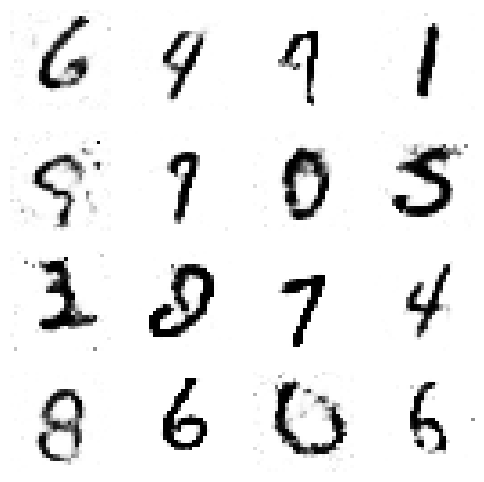

Epoch [200], Step [500], D_loss: 1.3810, G_loss: 0.7949, D(x): 0.52, D(G(z)): 0.43
Inception Score: 8.9632 ± 0.3238
FID: 0.0002
Mode Coverage: 10/10, KL: 0.0349
Class Counts: {8: 49, 9: 92, 2: 85, 5: 98, 7: 127, 3: 126, 1: 123, 6: 68, 4: 111, 0: 121}
SSIM (avg over 100): 0.2864
Discriminator Accuracy - Real: 0.7150, Fake: 0.6260


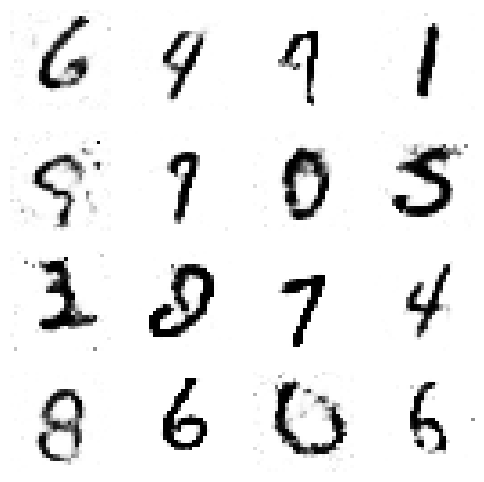

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
from collections import Counter
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
import matplotlib.pyplot as plt
import math
import itertools
from scipy import linalg
import json
from IPython import display  # 正确导入 display 模块

# 设置随机种子
seed = 67890
torch.manual_seed(seed)
np.random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 数据加载
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_dataset = MNIST(root='./data/', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)


class Vsig(nn.Module):
    def __init__(self, init_sigma=1.0):
        super().__init__()
        # 用 log_sigma 做参数，exp 后天然保证正数
        self.log_sigma = nn.Parameter(torch.tensor(math.log(init_sigma), dtype=torch.float32))

    def forward(self, input):
        sigma = torch.exp(self.log_sigma) + 1e-6
        return torch.sigmoid(input / sigma)   # 用 torch.sigmoid,不要手写
        
# 判别器
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            Vsig()
        )

    def forward(self, x):
        x = x.view(x.size(0), 784)
        out = self.model(x)
        return out.view(-1, 1)

# 生成器
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, x):
        x = x.view(x.size(0), 100)
        return self.model(x)

# 训练器
discriminator = Discriminator().to(device)
generator = Generator().to(device)
criterion = nn.BCELoss()
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=0.0002)
g_optimizer = torch.optim.Adam(generator.parameters(), lr=0.0002)

def train_discriminator(real_images, real_labels, fake_images, fake_labels):
    discriminator.zero_grad()
    real_output = discriminator(real_images)
    real_loss = criterion(real_output, real_labels)

    fake_output = discriminator(fake_images)
    fake_loss = criterion(fake_output, fake_labels)

    d_loss = real_loss + fake_loss
    d_loss.backward()
    d_optimizer.step()
    return d_loss, real_output, fake_output

def train_generator(fake_images, real_labels):
    generator.zero_grad()
    output = discriminator(fake_images)
    g_loss = criterion(output, real_labels)
    g_loss.backward()
    g_optimizer.step()
    return g_loss

# 分类器（用于 IS、Mode）
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(128 * 3 * 3, 128)
        self.fc2 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 128 * 3 * 3)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return F.softmax(self.fc2(x), dim=1)

def train_classifier(classifier, loader, epochs=3):
    classifier.train()
    optimizer = torch.optim.Adam(classifier.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    for epoch in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            preds = classifier(x)
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()

# FID feature extractor
class FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1))
        )

    def forward(self, x):
        x = self.features(x)
        return x.view(x.size(0), -1)

# 指标计算
def calculate_inception_score(images, classifier, splits=10):
    classifier.eval()
    with torch.no_grad():
        images = images.view(-1, 1, 28, 28)
        N = images.size(0)
        scores = []
        for i in range(splits):
            part = images[i * (N // splits):(i + 1) * (N // splits)]
            preds = classifier(part)
            kl = preds * (torch.log(preds + 1e-8) - torch.log(preds.mean(dim=0, keepdim=True) + 1e-8))
            scores.append(torch.exp(kl.sum(dim=1).mean()))
        return torch.stack(scores).mean().item(), torch.stack(scores).std().item()

def calculate_fid(real, fake):
    mu1, sigma1 = real.mean(0), np.cov(real.T)
    mu2, sigma2 = fake.mean(0), np.cov(fake.T)
    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)
    if np.iscomplexobj(covmean): covmean = covmean.real
    return diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)

def calculate_mode_score(images, classifier):
    classifier.eval()
    with torch.no_grad():
        preds = classifier(images.view(-1, 1, 28, 28))
        labels = preds.argmax(dim=1).cpu().numpy()
        counts = Counter(labels)
        covered = len(counts)
        total = len(labels)
        kl = 0
        for i in range(10):
            p = counts.get(i, 0) / total
            if p > 0: kl += p * np.log(p / 0.1)
        return covered, kl, counts

def calculate_ssim(img1, img2):
    mu1, mu2 = img1.mean(), img2.mean()
    sigma1 = ((img1 - mu1) ** 2).mean()
    sigma2 = ((img2 - mu2) ** 2).mean()
    sigma12 = ((img1 - mu1) * (img2 - mu2)).mean()
    c1, c2 = 0.01**2, 0.03**2
    return ((2 * mu1 * mu2 + c1) * (2 * sigma12 + c2)) / ((mu1**2 + mu2**2 + c1) * (sigma1 + sigma2 + c2))


# ========= GAN 训练 ==========
test_noise = torch.randn(16, 100).to(device)
fig, ax = plt.subplots(4, 4, figsize=(6, 6))
for i, j in itertools.product(range(4), range(4)):
    ax[i, j].axis('off')

for epoch in range(200):
    for n, (real_imgs, _) in enumerate(train_loader):
        real_imgs = real_imgs.to(device)
        real_labels = torch.ones(real_imgs.size(0), 1).to(device)
        fake_labels = torch.zeros(real_imgs.size(0), 1).to(device)

        z = torch.randn(real_imgs.size(0), 100).to(device)
        fake_imgs = generator(z)

        d_loss, d_real, d_fake = train_discriminator(real_imgs, real_labels, fake_imgs.detach(), fake_labels)

        z = torch.randn(real_imgs.size(0), 100).to(device)
        fake_imgs = generator(z)
        g_loss = train_generator(fake_imgs, real_labels)

        if (n + 1) % 500 == 0:
            test_imgs = generator(test_noise).detach().cpu()
            for k in range(16):
                i, j = k // 4, k % 4
                ax[i, j].imshow(1-test_imgs[k].view(28, 28), cmap='gray')
            display.clear_output(wait=True)
            display.display(plt.gcf())
            
            plt.savefig(f"D:/PRE2025/resultsvig/epoch_{epoch}.png")
            print(f"Epoch [{epoch+1}], Step [{n+1}], D_loss: {d_loss.item():.4f}, G_loss: {g_loss.item():.4f}, D(x): {d_real.mean().item():.2f}, D(G(z)): {d_fake.mean().item():.2f}")

# ========= 训练完成后评估 ==========

def evaluate_gan_quality(generator, discriminator, real_loader):
    generator.eval()
    discriminator.eval()
    
    # 1. 训练分类器（简单CNN）
    classifier = SimpleCNN().to(device)
    train_classifier(classifier, real_loader)
    
    # 2. 生成假图像和收集真实图像
    noise = torch.randn(1000, 100).to(device)
    with torch.no_grad():
        fake_images = generator(noise).view(-1, 1, 28, 28)

    # 从多个 batch 收集真实图像
    real_images = []
    for images, _ in real_loader:
        real_images.append(images)
        if sum([img.size(0) for img in real_images]) >= 1000:
            break
    real_images = torch.cat(real_images, dim=0)[:1000].to(device)

    # 3. Inception Score
    is_mean, is_std = calculate_inception_score(fake_images, classifier)
    print(f"Inception Score: {is_mean:.4f} ± {is_std:.4f}")
    
    # 4. FID
    feat_ext = FeatureExtractor().to(device)
    real_feat = feat_ext(real_images).detach().cpu().numpy()
    fake_feat = feat_ext(fake_images).detach().cpu().numpy()
    fid = calculate_fid(real_feat, fake_feat)
    print(f"FID: {fid:.4f}")
    
    # 5. Mode Score
    modes, kl, counts = calculate_mode_score(fake_images, classifier)
    print(f"Mode Coverage: {modes}/10, KL: {kl:.4f}")
    print(f"Class Counts: {dict(counts)}")
    
    # 6. SSIM
    ssims = [calculate_ssim(fake_images[i].cpu(), real_images[i].cpu()).item() for i in range(100)]
    print(f"SSIM (avg over 100): {np.mean(ssims):.4f}")
    
    # 7. 判别器准确率
    with torch.no_grad():
        real_acc = (discriminator(real_images) > 0.5).float().mean().item()
        fake_acc = (discriminator(fake_images) < 0.5).float().mean().item()
    print(f"Discriminator Accuracy - Real: {real_acc:.4f}, Fake: {fake_acc:.4f}")
    
    # 8. 保存结果
    results = {
        'inception_score': [float(is_mean), float(is_std)],
        'fid': float(fid),
        'mode_coverage': int(modes),
        'kl_divergence': float(kl),
        'class_counts': {int(k): int(v) for k, v in dict(counts).items()},
        'avg_ssim': float(np.mean(ssims)),
        'discriminator_real_acc': float(real_acc),
        'discriminator_fake_acc': float(fake_acc)
    }

    import os
    os.makedirs("D:/PRE2025/resultsvig", exist_ok=True)
    with open("D:/PRE2025/resultsvigevaluation_results.json", "w") as f:
        import json
        json.dump(results, f, indent=2)


evaluate_gan_quality(generator, discriminator, train_loader)